<style>
    :root {
        --accent: #38bdf8;
        --bg-dark: #0f172a;
    }
    .jp-Notebook { background-color: var(--bg-dark) !important; color: #e2e8f0 !important; }
    .jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2 { color: var(--accent) !important; border-bottom: 1px solid rgba(56, 189, 248, 0.2) !important; }
    .insight-card {
        background: rgba(56, 189, 248, 0.05);
        border-left: 4px solid var(--accent);
        padding: 1.2rem;
        border-radius: 8px;
        margin: 1rem 0;
    }
    .status-tag {
        background: var(--accent);
        color: var(--bg-dark);
        padding: 2px 8px;
        border-radius: 4px;
        font-weight: bold;
        font-size: 0.8em;
    }
</style>

# 🔬 Intel Core Ultra NPU: Unified GNN Benchmarking Suite

<span class="status-tag">ADVANCED ANALYTICS MODE</span>

This notebook provides a complete research pipeline with time-synchronized energy correlation for each model architecture.

In [1]:
import glob
from analysis.energy_monitor import run_with_energy_monitor
import os
import sys
import ctypes
import shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, HTML

is_admin = bool(ctypes.windll.shell32.IsUserAnAdmin())
print(f"Admin Privileges: {'✅ YES' if is_admin else '❌ NO - SoC Watch may not work correctly'}")

RESULTS_DIR = Path("results")
MODELS_DIR  = Path("models")
FIGURES_DIR = Path("paper/figures")

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
print("Environment Ready.")

Admin Privileges: ✅ YES
Environment Ready.


### 📦 Step 1: Model Suite Generation
GNN + baseline (CNN/NLP) models; standardized and quantized.

In [2]:
!{sys.executable} analysis/model_prep.py

Exporting GCN to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GCN_fp32.onnx...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Done.
GCN_int8.onnx already exists, skipping quantization.
Exporting GraphSAGE to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GraphSAGE_fp32.onnx...
[torch.onnx] Obtain model graph for `GraphSAGE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphSAGE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translat

W0503 20:27:28.047000 13072 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0503 20:27:28.047000 13072 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0503 20:27:28.047000 13072 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
c:\Users\yusuf\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0503 20:27:32.124000 13072 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0503 20:27:32.124000 13072 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi

### 📈 Step 2: Scalability & Timing Study
Executing models while recording high-precision start/end timestamps for energy correlation.

In [ ]:
import sys
from analysis.energy_monitor import run_with_energy_monitor

AUTO_ENERGY_MONITOR = True
cmd = f"{sys.executable} analysis/scalability_analyzer.py --iterations 100 --repeats 3 --profile --input-source auto --dataset-root data"
run_with_energy_monitor(cmd, "scalability", enabled=AUTO_ENERGY_MONITOR)

[ENERGY] Benchmark done in 5.9s
[ENERGY] Trace CSV: energy_log_scalability_trace.csv  (14 KB)


WindowsPath('results/energy_log_scalability_trace.csv')

### 📊 Step 2B: Density Sweep (Sparse → Medium → Dense)
Bu adım 3 gerçek dataset üzerinde aynı model setini çalıştırır:
- `ogbn-arxiv` (seyrek)
- `reddit` (orta)
- `ogbn-products` (dense-ish)
Amaç: “density-dependent performance trend” argümanını nicel olarak göstermek.

In [ ]:
import sys
from analysis.energy_monitor import run_with_energy_monitor

AUTO_ENERGY_MONITOR = True

# 3 dataset sweep (CPU vs NPU karşılaştırması için iki cihazı da koşar)
cmd = f"{sys.executable} analysis/density_sweep.py --models-dir models --results-dir results/density_sweep --datasets ogbn-arxiv,reddit,ogbn-products --iterations 100 --repeats 3 --profile --dataset-root data --auto-models --gnn-nodes 4096 --devices CPU,NPU"
run_with_energy_monitor(cmd, "density_sweep", enabled=AUTO_ENERGY_MONITOR)

### 📉 Step 2C: Density Trend Figure
Sweep sonrası çıktıları birleştirir ve yoğunluk (edges/node) ile performans trendini plot eder.

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

!{sys.executable} analysis/density_analyzer.py --sweep-dir results/density_sweep --out-dir results/density_sweep

# Main figure: display PNG, but require SVG export too.
png_candidates = [
    Path('results/density_sweep/density_vs_speedup.png'),
    Path('results/density_sweep/density_trend_speedup.png'),
]
svg_candidates = [
    Path('results/density_sweep/density_vs_speedup.svg'),
    Path('results/density_sweep/density_trend_speedup.svg'),
]

shown = False
for p in png_candidates:
    if p.exists():
        display(Image(filename=str(p)))
        shown = True
        break

if not shown:
    print('Trend figürü bulunamadı (önce Step 2B çalışmalı).')

# En az bir SVG de üretilmiş olmalı.
if not any(p.exists() for p in svg_candidates):
    print('UYARI: SVG çıktısı bulunamadı. (Beklenen: density_vs_speedup.svg veya density_trend_speedup.svg)')

## Figures (Hakemi ikna eden set)
Aşağıdaki grafikler doğrudan argüman taşır: density→performans, heavy-tail derece dağılımı, operator mix, CPU fallback, fusion gain korelasyonu.

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 1) Degree distribution (log-log)
!{sys.executable} analysis/figure_degree_distribution.py --datasets ogbn-arxiv,reddit,ogbn-products --dataset-root data --out-dir results/figures

deg = Path('results/figures/degree_distribution_loglog.png')
if deg.exists():
    display(Image(filename=str(deg)))

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 2) Operator breakdown (stacked bar; ONNX structural mix)
!{sys.executable} analysis/figure_operator_breakdown.py --models-dir models --out-dir results/figures

opmix = Path('results/figures/operator_breakdown_stacked.png')
if opmix.exists():
    display(Image(filename=str(opmix)))

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 3) CPU fallback heatmap (top operators)
!{sys.executable} analysis/figure_cpu_fallback_heatmap.py --results-dir results --out-dir results/figures --mode optimized --top-ops 25

hm = Path('results/figures/cpu_fallback_heatmap_optimized.png')
if hm.exists():
    display(Image(filename=str(hm)))

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 4) Fusion gain vs performance (uses latest scalability_matrix.csv in results/)
!{sys.executable} analysis/figure_fusion_gain_vs_performance.py --matrix-csv results/scalability_matrix.csv --out-dir results/figures

fg = Path('results/figures/fusion_gain_vs_latency_improvement.png')
if fg.exists():
    display(Image(filename=str(fg)))

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 4) Fusion gain vs performance (uses latest scalability_matrix.csv in results/)
!{sys.executable} analysis/figure_fusion_gain_vs_performance.py --matrix-csv results/scalability_matrix.csv --out-dir results/figures

fg = Path('results/figures/fusion_gain_vs_latency_improvement.png')
if fg.exists():
    display(Image(filename=str(fg)))

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# 5) Scaling: node size vs latency (opsiyonel; çalıştırması zaman alır)
!{sys.executable} analysis/scaling_sweep.py --dataset ogbn-arxiv --device NPU --dataset-root data --sizes 512,1024,2048,4096 --model GCN --out-dir results/scaling_sweep

sc = Path('results/scaling_sweep/scaling_nodes_vs_latency.png')
if sc.exists():
    display(Image(filename=str(sc)))

### 🔍 Step 3: Operator Profiling
Deep-dive into graph fusion and bottleneck identification.

In [4]:
!{sys.executable} analysis/profiling_analyzer.py


RESEARCH METRICS SUMMARY
----------------------------------------
Fusion Gain Ratio (FGR): 0.9991
Compilation Efficiency Index (CEI): 0.0000
NPU Support Ratio (Optimized): 33.1%
Baseline Latency: 59.13 ms
Optimized Latency: 59.18 ms
Latency Reduction: 0.00 ms

Detailed analysis complete.


### 💻 Step 4: Hardware Comparison
Benchmarking all models across CPU, GPU, and NPU.

In [5]:
!{sys.executable} analysis/hw_comparison_runner.py

Found 16 models.

Target: APPNP_fp32.onnx
[20:28:07] Starting 3-way hardware comparison for: APPNP_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[20:28:07] Testing device: CPU...
  -> Repeat 1/1...
[20:28:13] Device CPU completed (1 runs) in 5.19 seconds.
[20:28:13] Testing device: GPU...
  -> Repeat 1/1...
[20:28:19] Device GPU completed (1 runs) in 6.73 seconds.
[20:28:20] Testing device: NPU...
  -> Repeat 1/1...
[20:28:23] Device NPU completed (1 runs) in 2.96 seconds.
[20:28:23] Hardware comparison complete.
Total time: 15.73 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\APPNP_fp32
[ENERGY] Benchmark done in 30.9s
[ENERGY] Trace CSV: energy_log_hw_comp_APPNP_fp32_trace.csv  (40 KB)

Target: APPNP_int8.onnx
[20:28:44] Starting 3-way hardware comparison for: APPNP_int8.onnx
Configuration: 1 repeats of 30 iterations each.
[20:28:44] Testing device: CPU...
  -> Repeat 1/1...
[20:28:48] Device CPU completed (1 runs) in 4

C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\benchmark_runner.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\benchmark_runner.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\benchmark_runner.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\benchmark_runner.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
c:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\hw_comparison.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analysis\benchmark_runner.py:138: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\analy

### 🛡️ Step 4.5: Validation
Verifying that all models and output artifacts are generated correctly.

In [6]:
!{sys.executable} analysis/verify_pipeline.py

[OK] Active models found: 16
[OK] All active ONNX models pass onnx.checker.
[OK] hw_comparison outputs complete.
[OK] scalability_matrix.csv present (16 rows).
[OK] scalability_matrix.csv covers all active models.


### 🔋 Step 5: Energy Correlation Analysis
Correlating Intel SoC Watch logs with model timestamps to extract precise power metrics per architecture.

In [7]:
!{sys.executable} analysis/energy_correlation.py

Energy data fully populated in scalability_matrix.csv.
                model  avg_npu_power_w  energy_j  inf_per_j
           APPNP_fp32        61.519194       NaN   1.561679
           APPNP_int8        43.751820       NaN   1.858922
       bert-tiny_fp32        39.482006       NaN   4.088855
       bert-tiny_int8        39.779756       NaN   2.958852
             GCN_fp32        42.180968       NaN   2.618486
             GCN_int8        42.560651       NaN   2.830038
             GIN_fp32        57.153980       NaN   0.444465
             GIN_int8        50.651871       NaN   0.511607
       GraphSAGE_fp32        50.267197       NaN   0.465577
       GraphSAGE_int8        50.506679       NaN   0.501065
GraphTransformer_fp32        42.605494       NaN   2.273600
GraphTransformer_int8        41.009478       NaN   2.655900
     mobilenetv2_fp32        42.093337       NaN  10.137995
     mobilenetv2_int8        39.616568       NaN   3.624886
        resnet50_fp32        51.654113       

## 📊 Research Visualizations
This section generates the 7 most important visualizations for the academic publication. 
All plots use **IEEE-standard styling**, **Times New Roman fonts**, and are exported at **300 DPI** in both PNG and SVG formats.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import gc
import os
from pathlib import Path
from adjustText import adjust_text
from matplotlib.lines import Line2D

# Kendi kütüphanelerimizi ve stillerimizi yükleyelim
import analysis.plot_config
importlib.reload(analysis.plot_config)
from analysis.plot_config import apply_ieee_style, savefig_ieee, IEEE_COLORS


# 1. IEEE Standart Stilini Uygula
apply_ieee_style()

# 2. Verileri Temizleyerek Yükle
def get_final_benchmark_data():
    if not os.path.exists("results/scalability_matrix.csv"):
        print("⚠️ HATA: 'results/scalability_matrix.csv' bulunamadı! Lütfen önce benchmarkları çalıştırın.")
        return pd.DataFrame()
        
    df = pd.read_csv("results/scalability_matrix.csv")
    
    # Akademik Filtreleme: Çalışmayan veya stabil olmayan modelleri temizle
    # SGC ve GAT modelleri analiz dışı bırakılmıştır.
    exclude_list = ['SGC', 'GAT']
    df = df[~df['model'].str.contains('|'.join(exclude_list), case=False, na=False)]
    
    # Model isimlerini görselleştirme için kısalt (Örn: GCN_fp32 -> GCN)
    df['model_short'] = df['model'].apply(lambda x: x.split('_')[0].upper())
    
    # AI ve GFLOPS hesaplamalarını doğrula
    df['gflops'] = (df['flops'] / (df['o_mean_ms'] / 1000.0)) / 1e9
    
    print(f"✅ Veri başarıyla yüklendi: {len(df)} model analiz için hazır.")
    return df

# Ana DataFrame'i oluştur (Bu değişkeni tüm alt hücreler kullanacak)
df_res = get_final_benchmark_data()

# Temizlik yap (RAM'i rahatlat)
gc.collect()


✅ Veri başarıyla yüklendi: 16 model analiz için hazır.


20

### 0️⃣ (New) Basit Latency Modeli
Bu adım, ölçülen gecikmeyi (ms) basit doğrusal bir modelle açıklamaya çalışır.
Amaç: *en azından* sistem/graph boyutu (node/edge) ve model karmaşıklığı (parametre/AI) ile gecikme arasındaki ilişkiyi nicelleştirmek.

In [ ]:
import sys
from pathlib import Path
from IPython.display import Image, display

# Bu script, results/scalability_matrix.csv içinden basit OLS modeli fit eder
!{sys.executable} analysis/latency_model.py --results-dir results

# Çıktı figürünü göster
img = Path('results/latency_model_pred_vs_actual.png')
if img.exists():
    display(Image(filename=str(img)))
else:
    print('Latency model figürü bulunamadı (önce Step 2 çalışmalı).')

### 1️⃣ Roofline Model: Operational Intensity
Analyzes whether models are compute-bound or memory-bound on the Intel NPU.

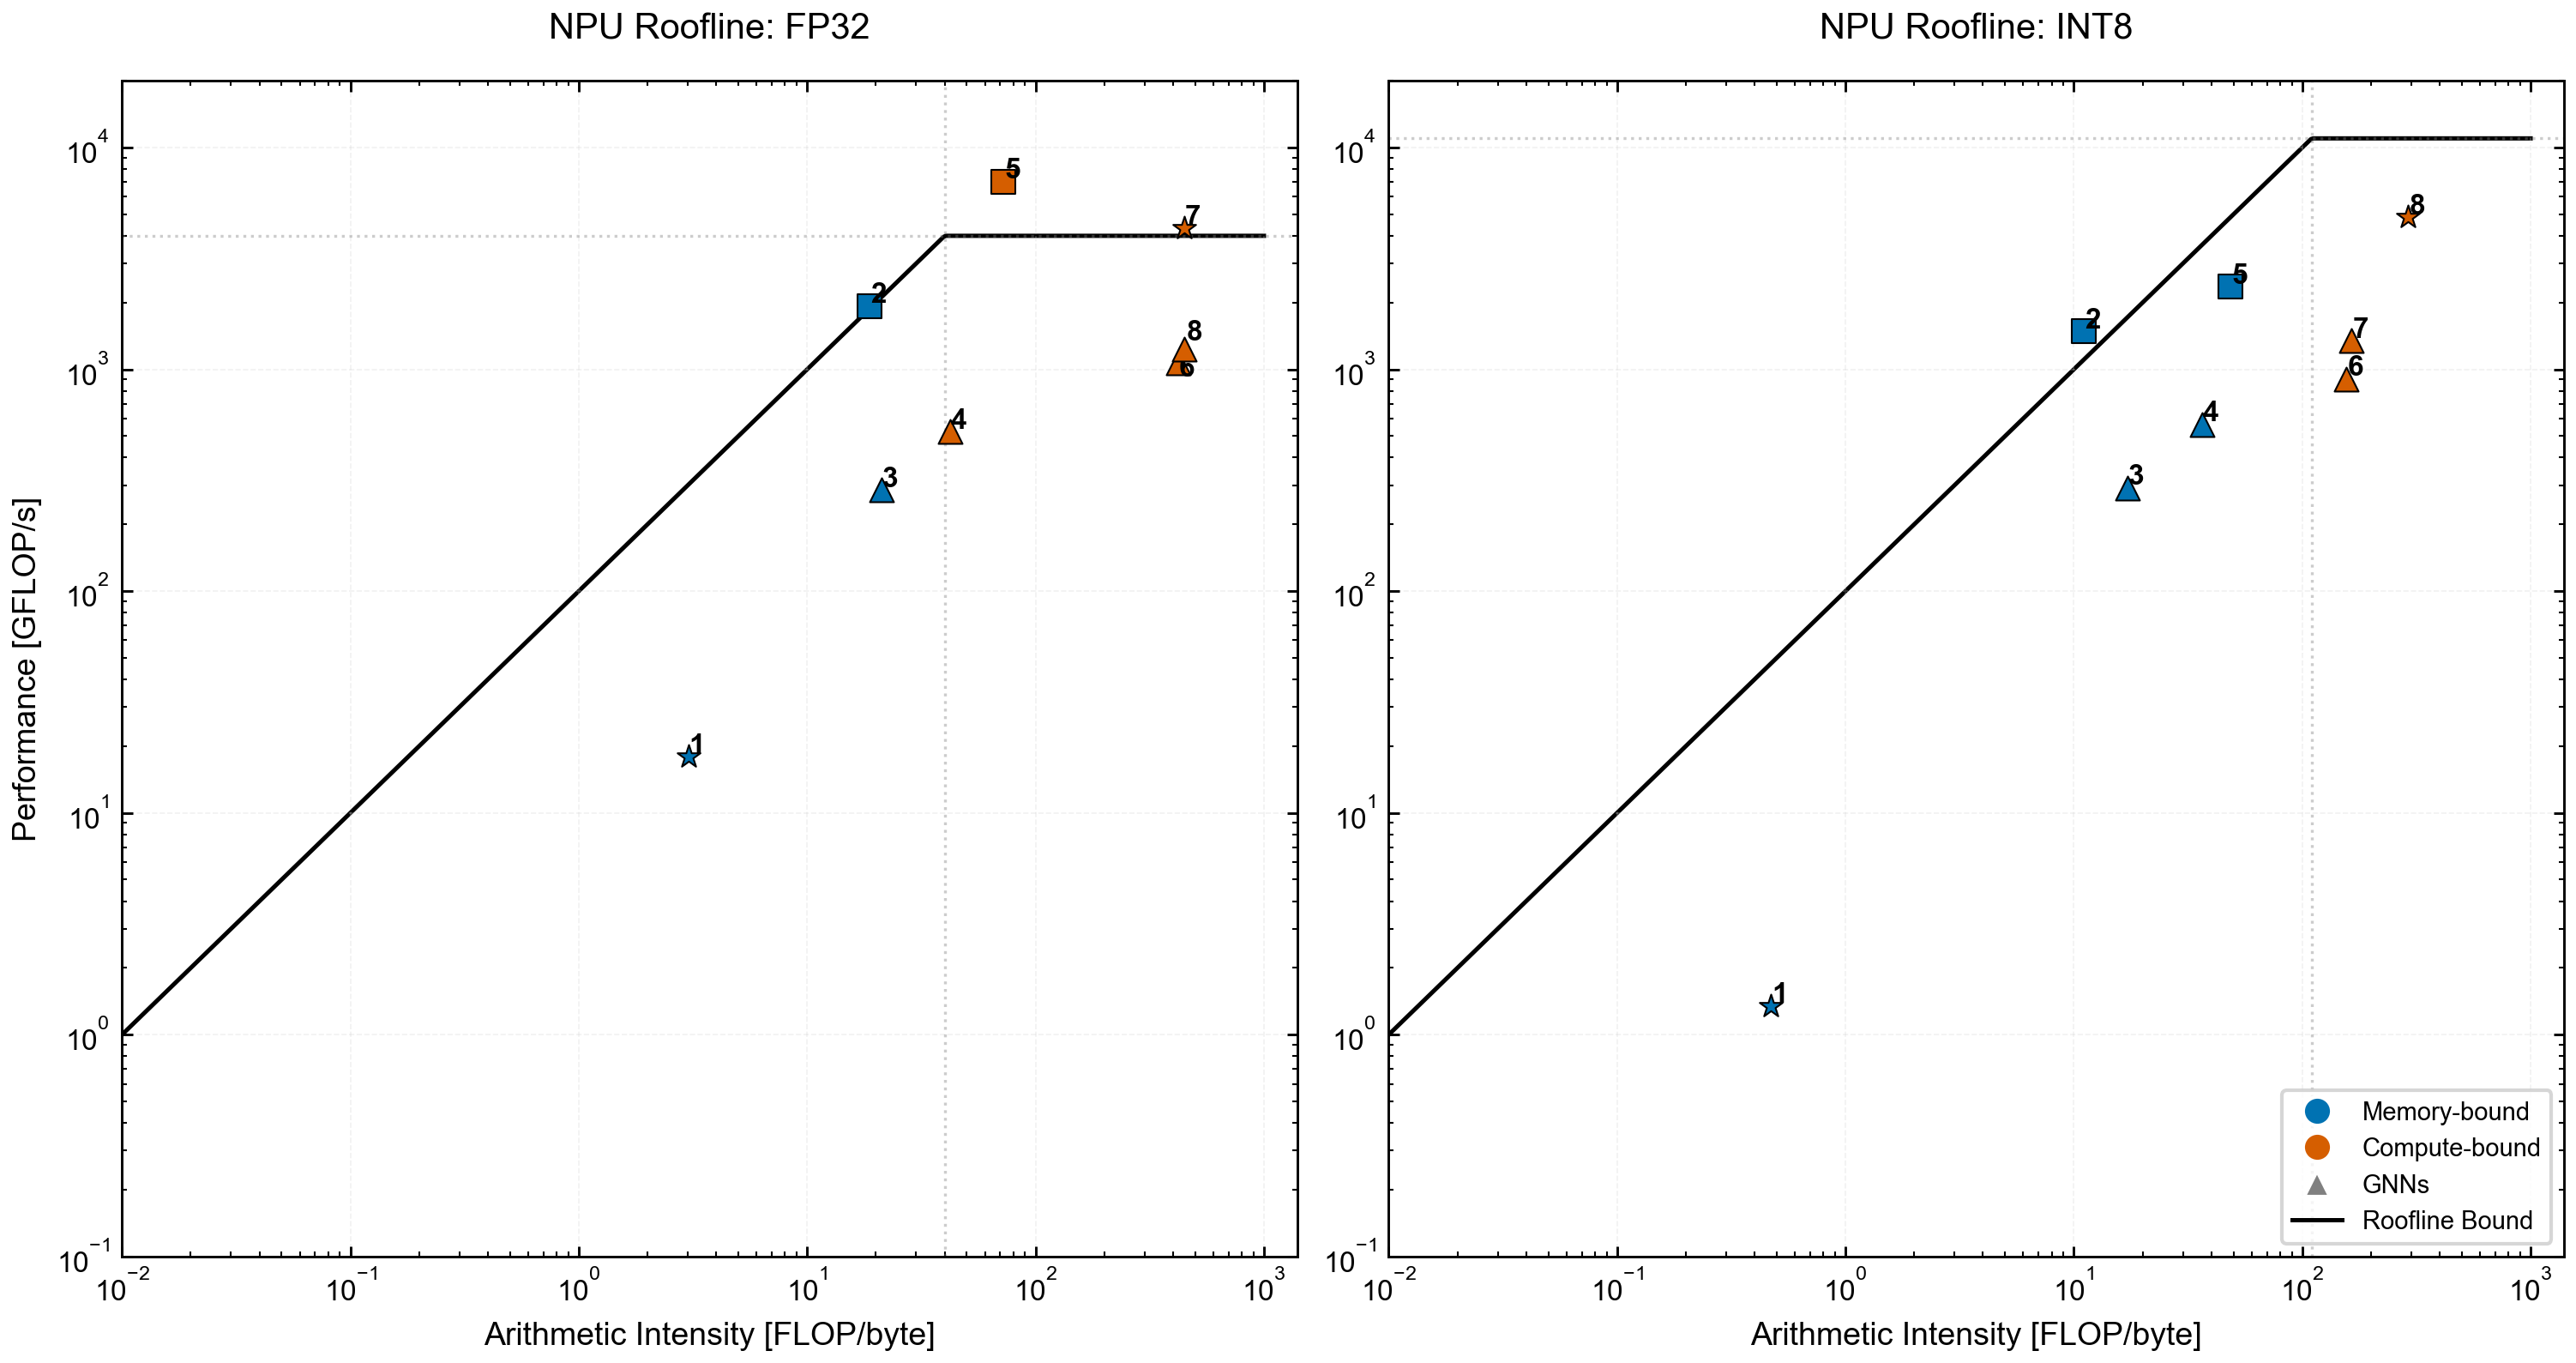


TABLE I: Model Index Reference Map
FP32-1       | BERT-TINY
FP32-2       | RESNET50
FP32-3       | GIN
FP32-4       | GRAPHSAGE
FP32-5       | MOBILENETV2
FP32-6       | APPNP
FP32-7       | GRAPHTRANSFORMER
FP32-8       | GCN
INT8-1       | BERT-TINY
INT8-2       | RESNET50
INT8-3       | GIN
INT8-4       | GRAPHSAGE
INT8-5       | MOBILENETV2
INT8-6       | APPNP
INT8-7       | GCN
INT8-8       | GRAPHTRANSFORMER


In [7]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
from matplotlib.lines import Line2D
import analysis.plot_config
importlib.reload(analysis.plot_config)
from analysis.plot_config import apply_ieee_style, savefig_ieee, IEEE_COLORS

# 1. IEEE Stilini ve Modern-Akademik Ayarları Yükle
apply_ieee_style()

# 2. NPU Teknik Parametreleri (Core Ultra için Tahmini)
peak_gflops_fp32 = 4000.0  
peak_gflops_int8 = 11000.0 
peak_bw = 100.0      # LPDDR5 Bant Genişliği (GB/s)

ai_line = np.logspace(-2, 3, 500)

# 3. Figür Hazırlığı (Sıkışmayı önleyen genişletilmiş boyut)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

precisions = [("FP32", ax1, peak_gflops_fp32, "fp32"), ("INT8", ax2, peak_gflops_int8, "int8")]
model_mapping = {} # Numaralar için referans sözlüğü

for title, ax, peak, suffix in precisions:
    # Ridge Point (Kırılma Noktası) Çizimi
    ridge_ai = peak / peak_bw
    ax.axvline(ridge_ai, color="gray", ls=":", lw=0.8, alpha=0.4)
    ax.axhline(peak, color="gray", ls=":", lw=0.8, alpha=0.4)
    
    # Roofline Teorik Sınır Çizgisi
    roofline = np.minimum(peak, peak_bw * ai_line)
    ax.plot(ai_line, roofline, "k-", lw=1.2, label="Theoretical Limit", zorder=1)
    
    texts = []
    # İlgili hassasiyetteki (FP32/INT8) modelleri filtrele
    df_sub = df_res[df_res['model'].str.contains(suffix, case=False, na=False)].sort_values("ai")
    
    for i, (_, row) in enumerate(df_sub.iterrows(), 1):
        # Güvenli GFLOPS hesaplama
        lat_ms = max(row["o_mean_ms"], 0.0001)
        gflops = (row["flops"] / (lat_ms / 1000.0)) / 1e9
        m_name = row["model"].upper()
        
        # Renk Kodlaması: Mavi (Memory-bound) vs Turuncu (Compute-bound)
        point_color = IEEE_COLORS[0] if row["ai"] < ridge_ai else "#D55E00" 
        
        # Sembol Kodlaması (Marker Diversity)
        if any(x in m_name for x in ["GCN", "GSAGE", "GIN", "APPNP", "SAGE"]): 
            marker = "^" # GNN: Üçgen
        elif any(x in m_name for x in ["BERT", "TRANSFORMER"]): 
            marker = "*" # Transformer: Yıldız
        else: 
            marker = "s" # CNN/Baselines: Kare
            
        if gflops > 0.01 and row["ai"] > 0.001:
            ax.scatter(row["ai"], gflops, s=45, marker=marker, color=point_color, edgecolors="k", lw=0.5, zorder=3)
            # Numaralandırma Stratejisi (Clutter çözümü)
            t = ax.text(row["ai"], gflops, str(i), fontsize=8, fontweight='bold')
            texts.append(t)
            model_mapping[f"{title}-{i}"] = row["model_short"].replace("_"+suffix, "")
    
    # Eksenler ve Limitler
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylim(0.1, 20000); ax.set_xlim(0.01, 1400)
    ax.set_box_aspect(1)
    ax.set_title(f"NPU Roofline: {title}", pad=12)
    ax.set_xlabel("Arithmetic Intensity [FLOP/byte]")
    if ax == ax1: ax.set_ylabel("Performance [GFLOP/s]")
    
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", color='gray', lw=0.4))

# 4. Sayfa Düzeni ve Lejant Ayarı
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.4, hspace=0, wspace=0.1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Memory-bound', markerfacecolor=IEEE_COLORS[0], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Compute-bound', markerfacecolor="#D55E00", markersize=8),
    Line2D([0], [0], marker='^', color='w', label='GNNs', markerfacecolor='gray', markersize=7),
    Line2D([0], [0], color='k', lw=1.2, label='Roofline Bound')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=7, frameon=True)

# 5. Vektörel (SVG) ve PNG Kayıt
savefig_ieee(fig, "results/roofline_final_academic")
plt.show()

# 6. Referans Tablosu (Bu tabloyu makalenize ekleyebilirsiniz)
print("\n" + "="*45)
print("TABLE I: Model Index Reference Map")
print("="*45)
for idx, m in model_mapping.items():
    print(f"{idx:<12} | {m}")


### 2️⃣ Multi-Hardware Performance Comparison
Compares speedup relative to CPU across NPU and GPU.

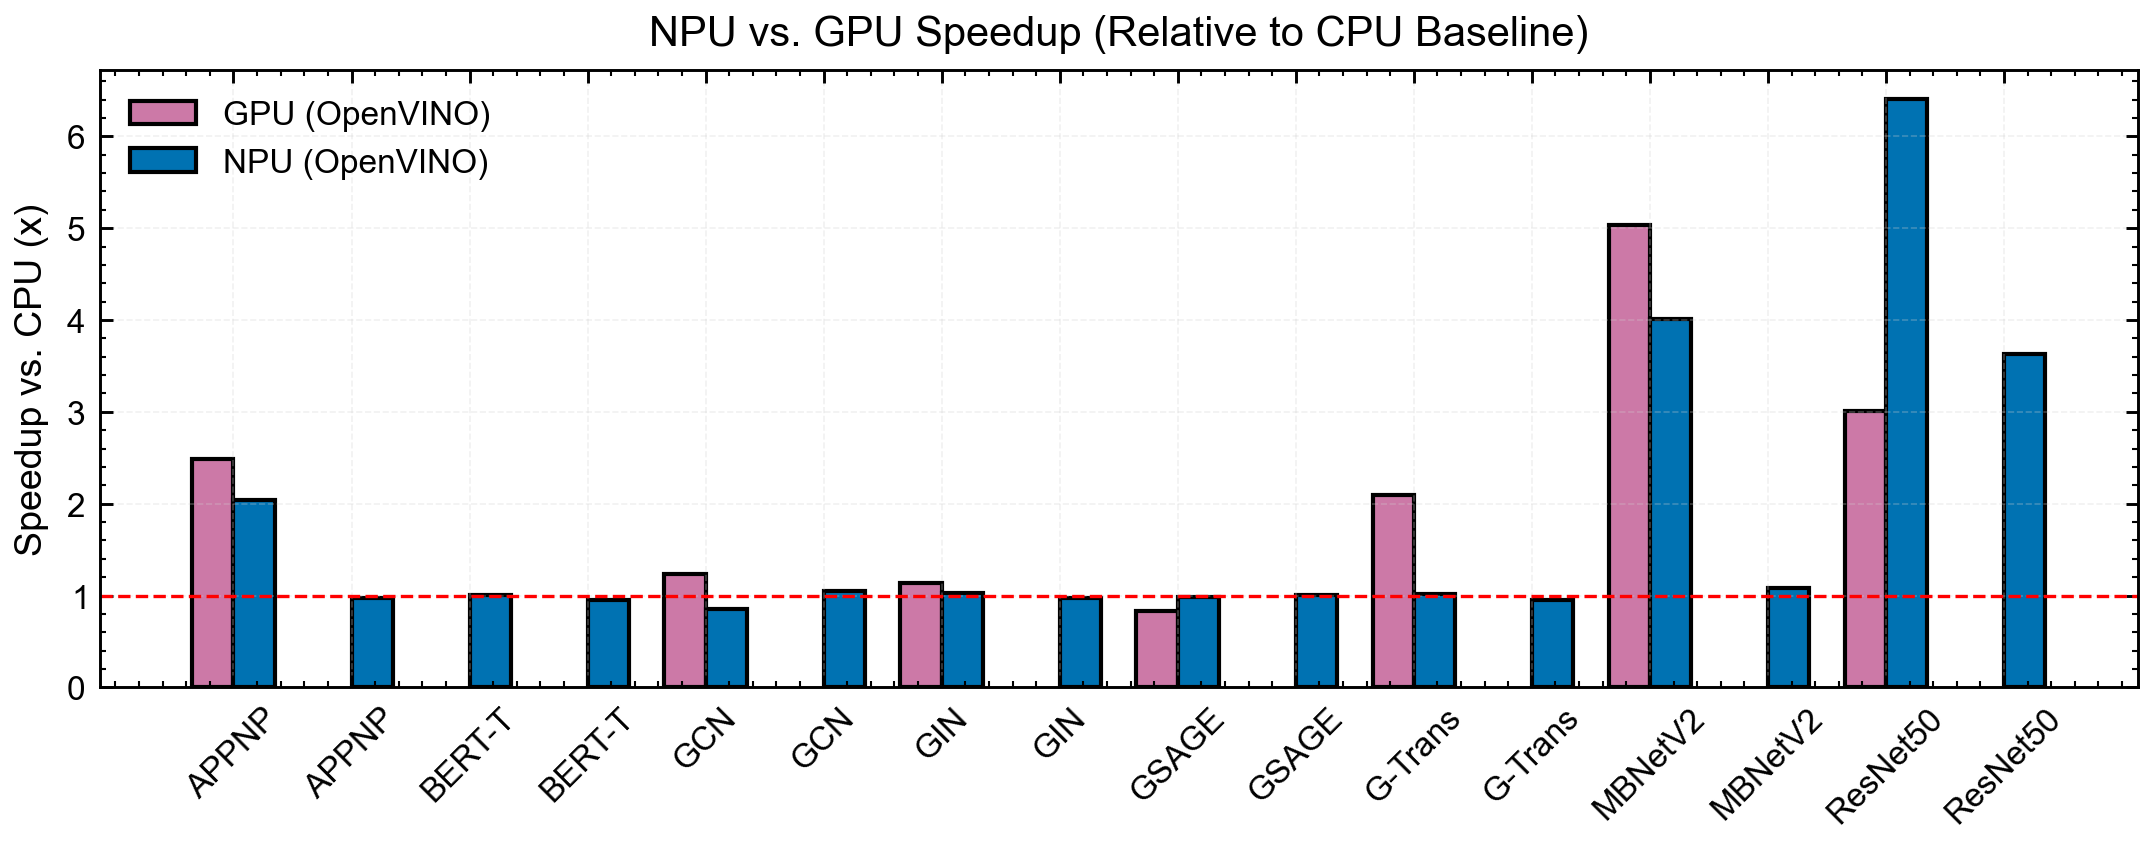

In [4]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from analysis.plot_config import shorten_label, DOUBLE_COL, IEEE_COLORS, savefig_ieee

hw_summaries = glob.glob("results/hw_comparison/*/hw_comparison_summary.csv")
hw_list = []
for f in hw_summaries:
    if "GAT" in f: continue
    m_name = Path(f).parent.name
    tdf = pd.read_csv(f)
    cpu = tdf[tdf['device'] == 'CPU']['avg_latency_ms'].mean()
    gpu = tdf[tdf['device'] == 'GPU']['avg_latency_ms'].mean()
    npu = tdf[tdf['device'] == 'NPU']['avg_latency_ms'].mean()
    hw_list.append({'model': m_name, 'CPU': cpu, 'GPU': gpu, 'NPU': npu})

df_hw = pd.DataFrame(hw_list).dropna(subset=["CPU", "NPU"])
df_hw['label'] = df_hw['model'].apply(shorten_label)
df_hw['GPU_Speedup'] = df_hw['CPU'] / df_hw['GPU']
df_hw['NPU_Speedup'] = df_hw['CPU'] / df_hw['NPU']

fig, ax = plt.subplots(figsize=DOUBLE_COL)
x = np.arange(len(df_hw))
w = 0.35
ax.bar(x - w/2, df_hw['GPU_Speedup'], w, label='GPU (OpenVINO)', color=IEEE_COLORS[3], edgecolor='k')
ax.bar(x + w/2, df_hw['NPU_Speedup'], w, label='NPU (OpenVINO)', color=IEEE_COLORS[0], edgecolor='k')

ax.axhline(1, color='red', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(df_hw['label'], rotation=45)
ax.set_ylabel("Speedup vs. CPU (x)")
ax.set_title("NPU vs. GPU Speedup (Relative to CPU Baseline)")
ax.legend()
savefig_ieee(fig, "results/hw_hardware_comparison")
plt.show()


### 3️⃣ Optimization Speedup (Baseline vs. NPU-Optimized)
Shows the impact of graph-level optimizations on execution time.

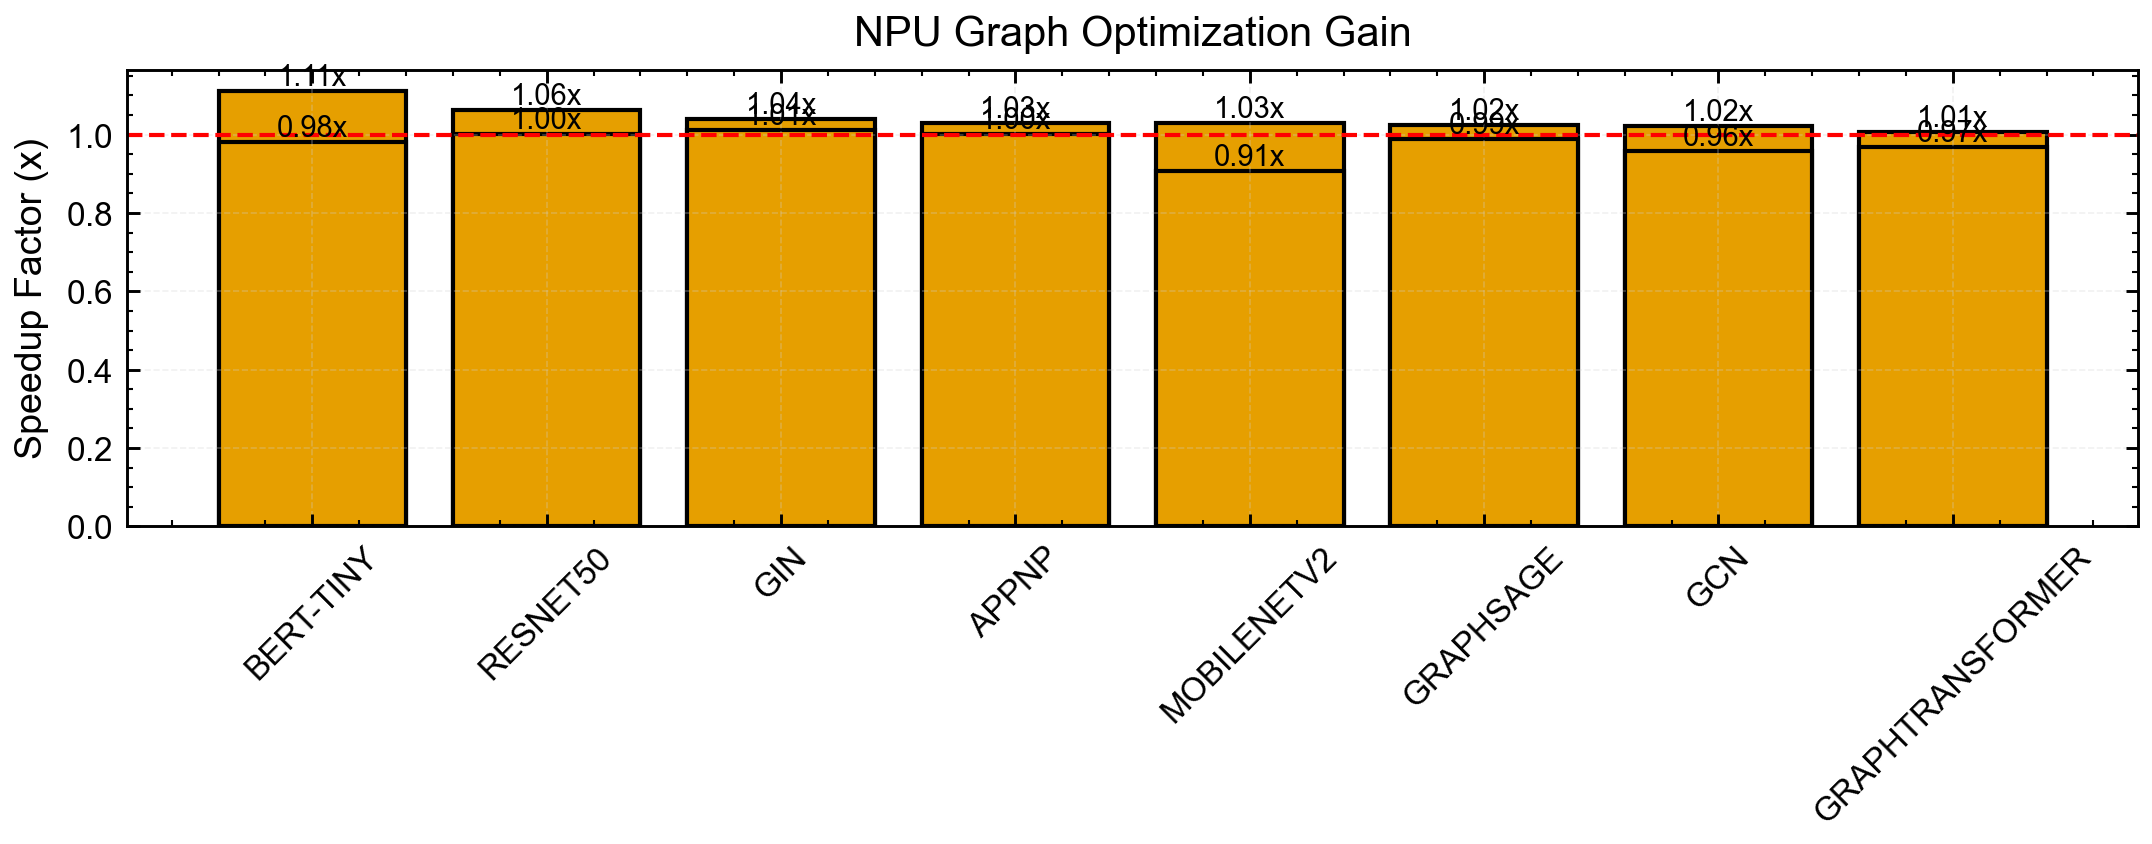

In [5]:
df_sorted = df_res.sort_values("speedup", ascending=False)
fig, ax = plt.subplots(figsize=DOUBLE_COL)
bars = ax.bar(df_sorted["model_short"], df_sorted["speedup"], color=IEEE_COLORS[1], edgecolor='k')
ax.axhline(1.0, color='r', ls='--', lw=1)
ax.set_ylabel("Speedup Factor (x)")
ax.set_title("NPU Graph Optimization Gain")
plt.xticks(rotation=45)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f"{bar.get_height():.2f}x", 
            ha='center', va='bottom', fontsize=7)

savefig_ieee(fig, "results/graph_optimization_speedup") # FINAL_ kaldırıldı
plt.show()


### 4️⃣ Energy Efficiency: Inferences per Joule
Measured using Intel SoC Watch with time-synchronized power correlation.

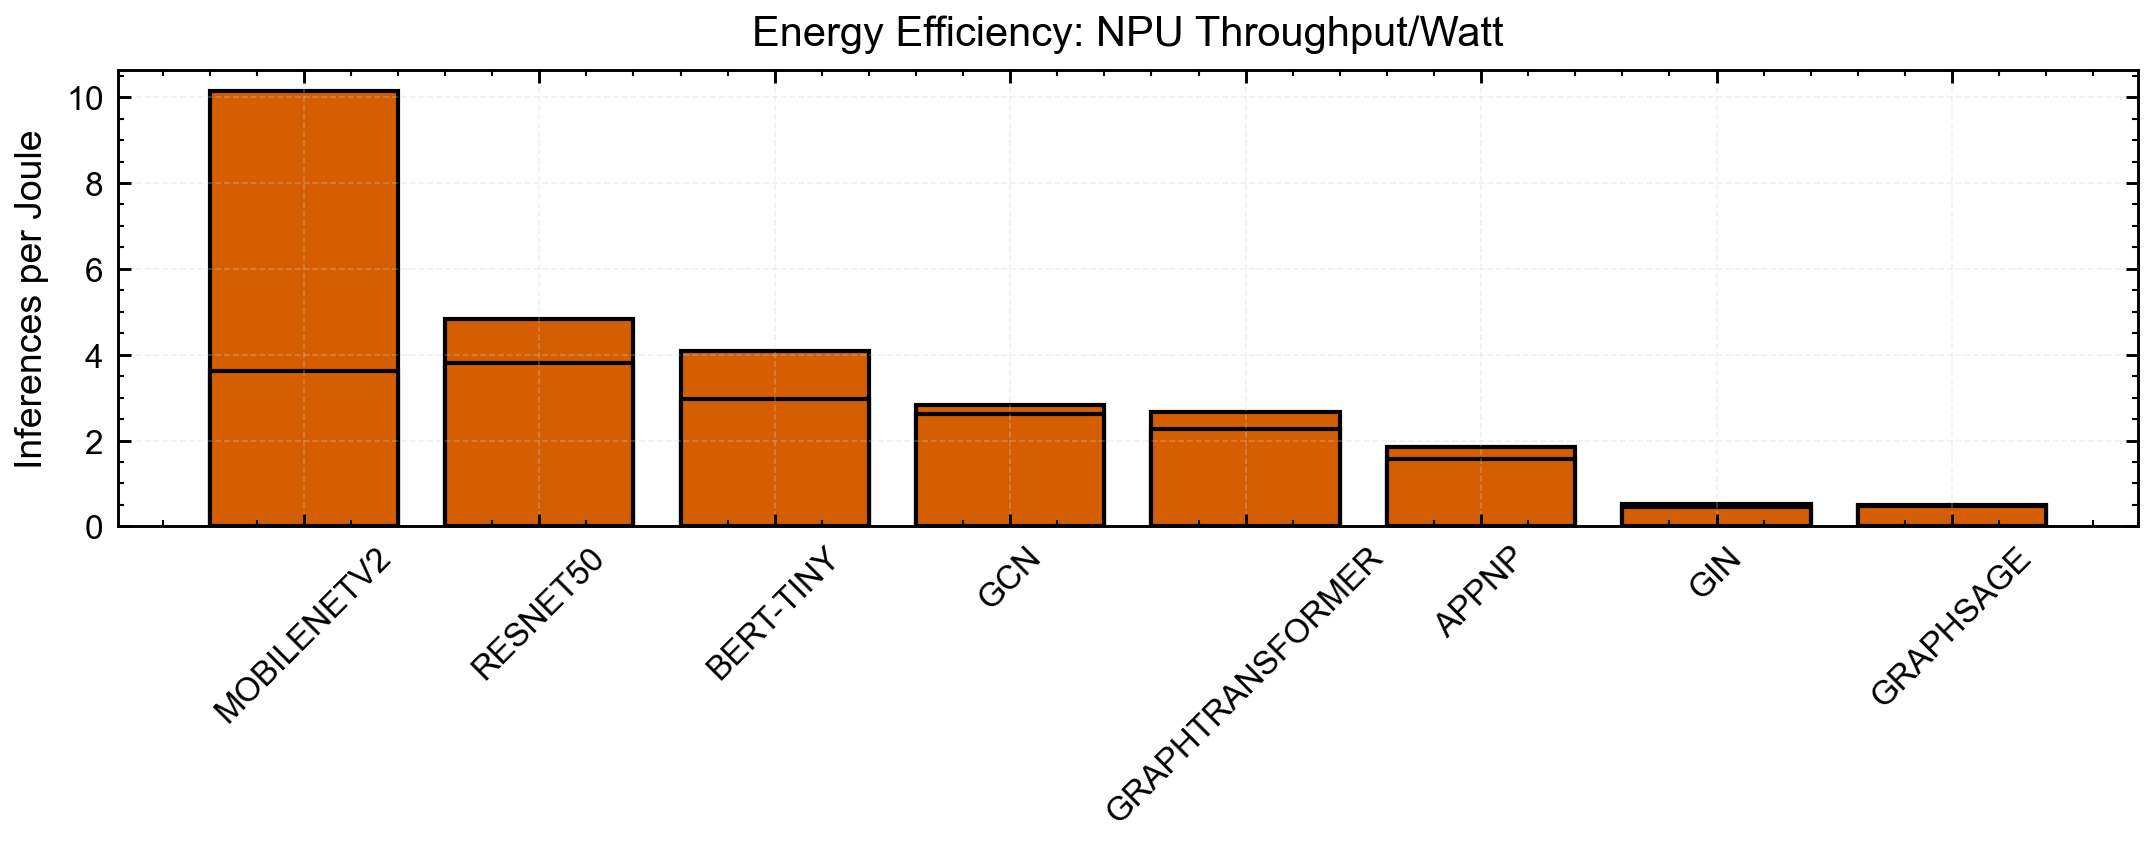

In [6]:
df_energy = df_res.dropna(subset=['inf_per_j']).sort_values("inf_per_j", ascending=False)
fig, ax = plt.subplots(figsize=DOUBLE_COL)
ax.bar(df_energy["model_short"], df_energy["inf_per_j"], color=IEEE_COLORS[4], edgecolor='k')
ax.set_ylabel("Inferences per Joule")
ax.set_title("Energy Efficiency: NPU Throughput/Watt")
plt.xticks(rotation=45)
savefig_ieee(fig, "results/npu_energy_efficiency") # FINAL_ kaldırıldı
plt.show()

### 5️⃣ Complexity vs. Latency Pareto Frontier
Visualizes the trade-off between model parameters and inference time.

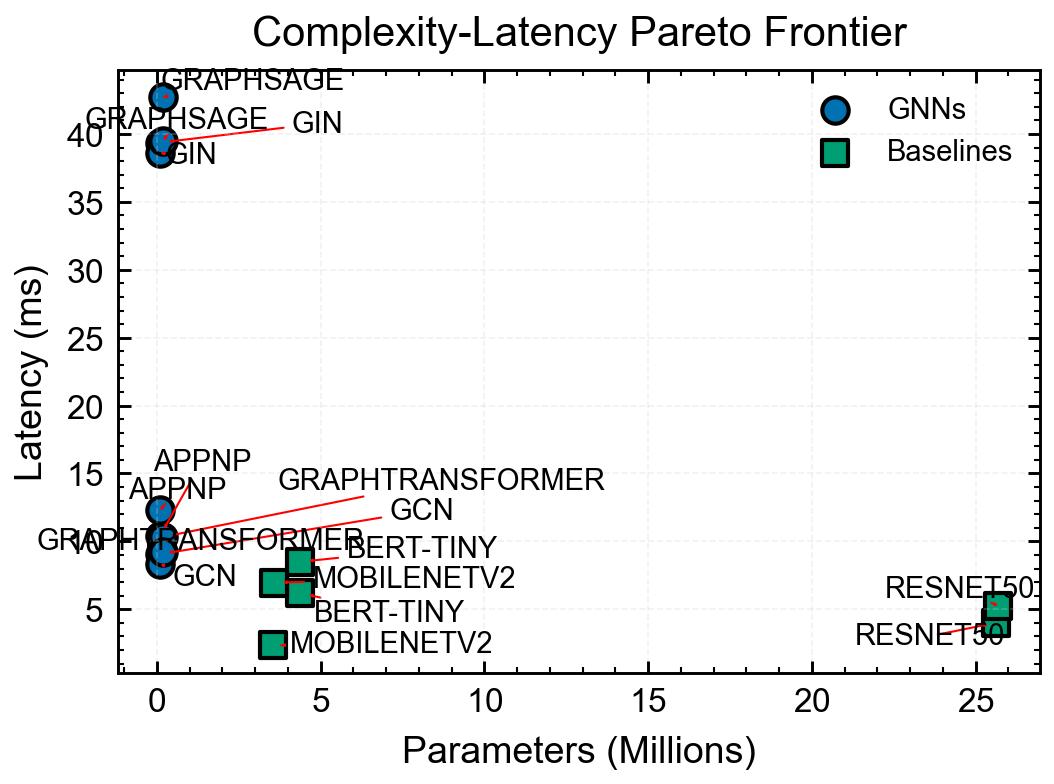

In [8]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
from analysis.plot_config import SINGLE_COL, IEEE_COLORS, savefig_ieee

# Grafik oluşturma ve Pareto Analizi
fig, ax = plt.subplots(figsize=SINGLE_COL)
gnns = df_res[~df_res['model'].str.contains('resnet|mobile|bert', case=False)]
baselines = df_res[df_res['model'].str.contains('resnet|mobile|bert', case=False)]

# Dağılım grafiği (Scatter plot)
ax.scatter(gnns["params_mil"], gnns["o_mean_ms"], c=IEEE_COLORS[0], label="GNNs", edgecolors='k', s=40)
ax.scatter(baselines["params_mil"], baselines["o_mean_ms"], c=IEEE_COLORS[2], label="Baselines", edgecolors='k', s=40, marker='s')

# Model isimlerini otomatik yerleştir
texts = []
for _, row in df_res.iterrows():
    texts.append(ax.text(row["params_mil"], row["o_mean_ms"], row["model_short"], fontsize=7))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='r', lw=0.5))

# Eksen ve Başlık Ayarları
ax.set_xlabel("Parameters (Millions)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Complexity-Latency Pareto Frontier")
ax.legend(fontsize=7)

# Kaydet ve Göster
savefig_ieee(fig, "results/complexity_latency_pareto")
plt.show()


### 6️⃣ Latency Breakdown: Compute, DMA, and Dispatch
Deep dive into time spent on memory transfers and kernel execution.

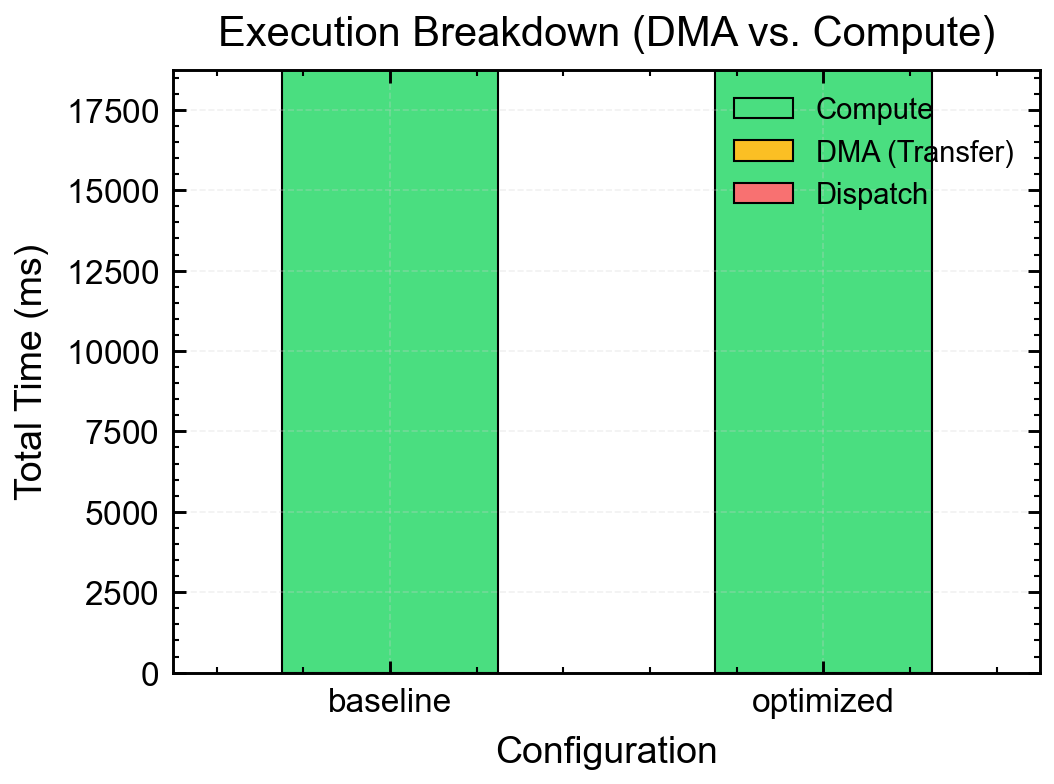

In [9]:
df_metrics = pd.read_csv("results/research_metrics.csv")
df_metrics = df_metrics.set_index('mode')

fig, ax = plt.subplots(figsize=SINGLE_COL)
categories = ['compute_ms', 'dma_ms', 'dispatch_ms']
colors = ['#4ade80', '#fbbf24', '#f87171']

df_metrics[categories].plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='k', linewidth=0.5)

ax.set_ylabel("Total Time (ms)")
ax.set_xlabel("Configuration")
ax.set_title("Execution Breakdown (DMA vs. Compute)")
ax.legend(["Compute", "DMA (Transfer)", "Dispatch"], fontsize=7)
plt.xticks(rotation=0)
savefig_ieee(fig, "results/execution_latency_breakdown") # FINAL_ kaldırıldı
plt.show()

### 7️⃣ Quantization Impact: FP32 vs. INT8 Throughput
Compares the performance gain achieved through 8-bit integer quantization.

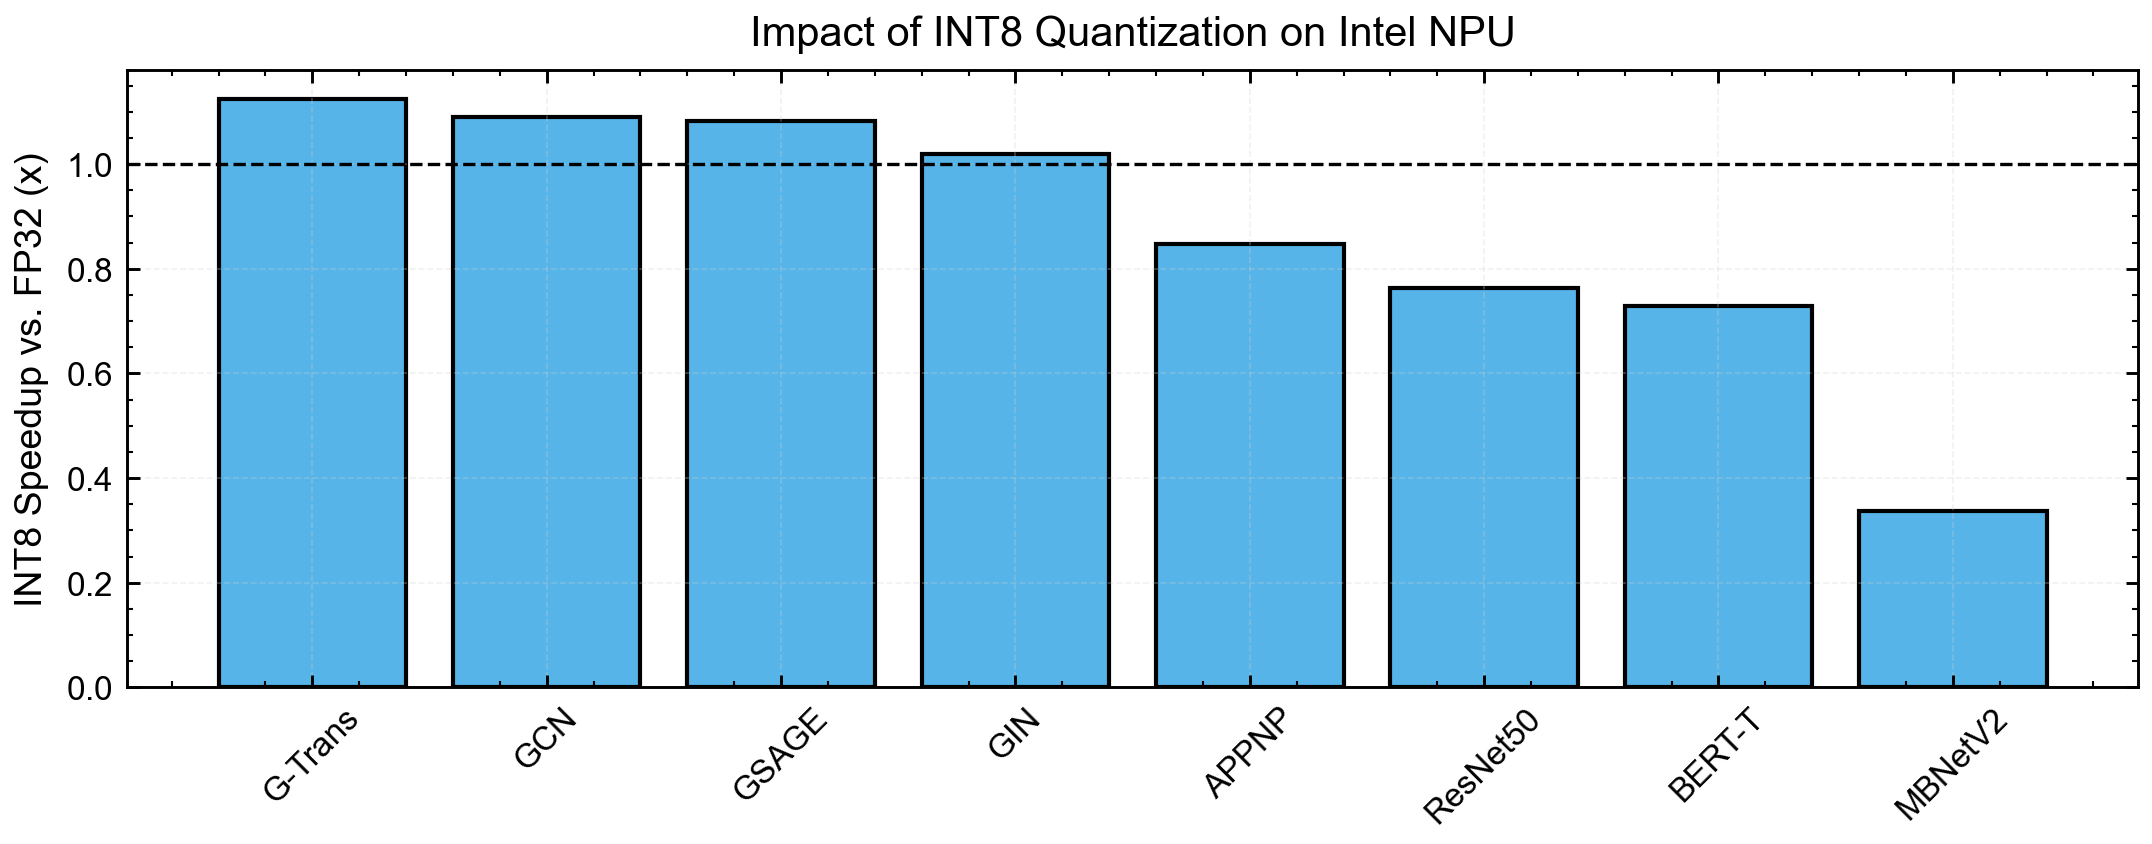

In [10]:
base_models = [m.replace("_fp32", "") for m in df_res['model'] if "_fp32" in m]
q_data = []
for bm in base_models:
    fp32_row = df_res[df_res['model'] == f"{bm}_fp32"]
    int8_row = df_res[df_res['model'] == f"{bm}_int8"]
    if not fp32_row.empty and not int8_row.empty:
        speedup = fp32_row['o_mean_ms'].values[0] / int8_row['o_mean_ms'].values[0]
        q_data.append({'model': shorten_label(bm), 'q_gain': speedup})

df_q = pd.DataFrame(q_data).sort_values('q_gain', ascending=False)

fig, ax = plt.subplots(figsize=DOUBLE_COL)
ax.bar(df_q['model'], df_q['q_gain'], color=IEEE_COLORS[5], edgecolor='k')
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_ylabel("INT8 Speedup vs. FP32 (x)")
ax.set_title("Impact of INT8 Quantization on Intel NPU")
plt.xticks(rotation=45)
savefig_ieee(fig, "results/quantization_performance_gain") # FINAL_ kaldırıldı
plt.show()